# Part 1, Black Scholes formula for European put/call option

User can enter queried inputs to get the 'fair value' of option, such inputs include:

- Volatility (typically standard deviation of an asset's given sample)
- The risk-free rate, typically the yield of a treasury bill
- The equity's current price
- The equity's strike price (expiry date, for Euro options)
- The number of years before expiry (typically one or two)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts
from scipy.stats import norm

def put_call_calc():
    
    S = float(input("\nEnter current Equity/Stock/Share price (S)"))
    K = float(input("\nEnter Strike price (K)"))
    r = float(input("\nEnter the the Risk-free rate as decimal, typically for treasury bills (r)"))
    sigma = float(input("\nEnter Volatility/Standard deviation of asset as decimal (sigma)"))
    t = float(input("\nEnter time to expiry (t)"))
    d1 = ((np.log(S/K) + (((r + (sigma**2)/2)) * t))) / (sigma * np.sqrt(t))
    d2 = d1 - sigma * np.sqrt(t)
    Call = S * sts.norm.cdf(d1) - K * np.exp(-r * t) * sts.norm.cdf(d2)
    Put = (K * np.exp(-r * t) * sts.norm.cdf(-d2)) - (S * sts.norm.cdf(-d1)) 
    print("\nYour Black-Scholes European Call Option has the value:", Call)
    print("Your Black-Scholes European Put Option has the value:", Put)

put_call_calc()


Enter current Equity/Stock/Share price (S) 145

Enter Strike price (K) 130

Enter the the Risk-free rate as decimal, typically for treasury bills (r) 0.05

Enter Volatility/Standard deviation of asset as decimal (sigma) 0.25

Enter time to expiry (t) 1



Your Black-Scholes European Call Option has the value: 26.633663456705634
Your Black-Scholes European Put Option has the value: 5.293488641798454


# Part 2, Simulating multiple equity paths using Geometric Brownian motion 

User can once again enter queried values which will then calibrate the appropriate price paths a specified number of times. Their input can be evaluated in/out of the money and a fair value can finally be determined

It should be noted that Black-Scholes contains a number of disadvantages, these limitations are addressed below:

- Constant volatility (homoskedasticity), volatility is often dynamic and asymetrical as noted by Engle (1986) and Black (1976)
- Jump risk can manifest in the form of discrete jumps (Merton, 1976)
- Relies on appropriate calibration (log-normal distribution) which can often be out-performed by other methods such as ANNs (Amilion, 2003)
- However, Black-Scholes still holds as a useful benchmark in periods of relative economic calmness
- Nonetheless, the lack of transaction costs, heteroskedasticity and sudden-jumps render the Black-Scholes model (under Geometric Brownian motion) problematic with fragile assumptions holding the validity of the model

As such, this does not serve as pure investment/trading/hedging advise but to be informative and as an opportunity to practice my statistics/stochastic process/financial skills,

Thank you for reading 


Enter a numerical seed e.g: 4001 4001

Please enter Y/N for inspection of Equity paths Y



Please enter some values for simulation...



Enter initial Equity/Stock/Share price (S0) 58
Enter Expected return (mu) 0.15
Enter Volatility/Standard deviation of asset as decimal (sigma) 0.2
Enter time in years (T) 1
Enter the number of Simulations you wish to see, e.g: 5,000 2000

Enter your desired number of paths 400

Please enter the Strike price: 63


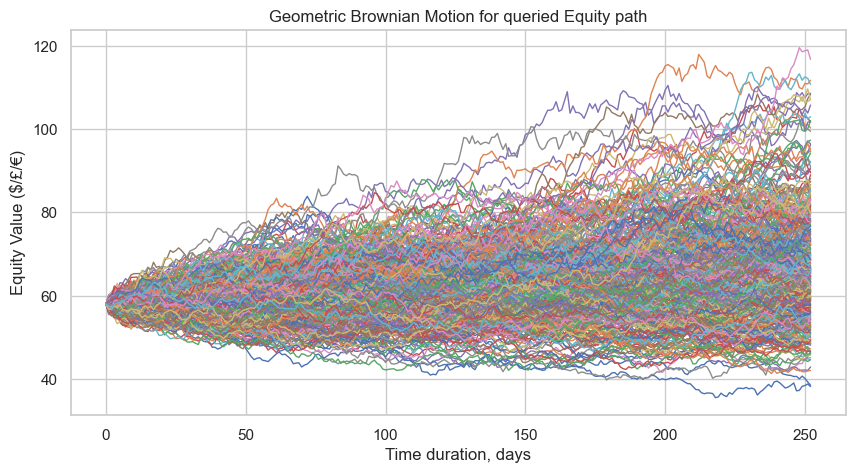

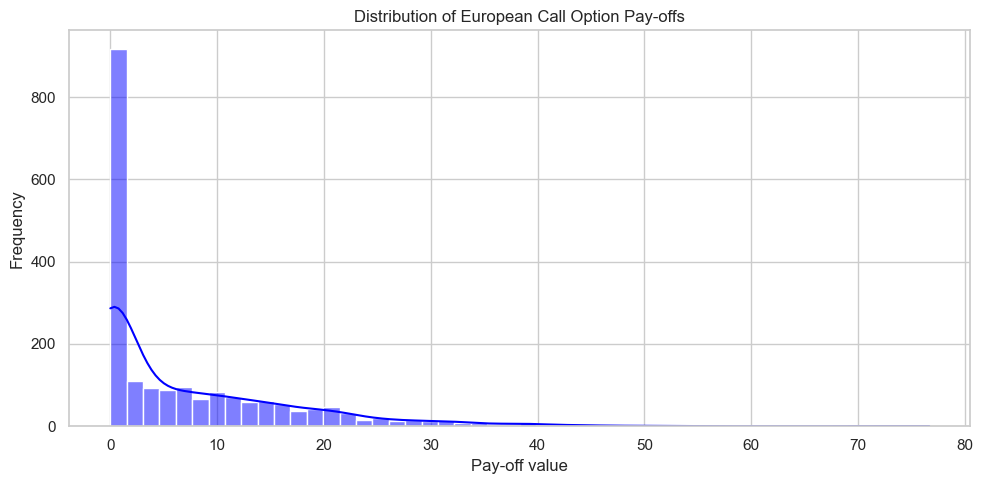

Enter the risk-free rate (e.g: T-bill 5% as 0.05) 0.03
Enter time in years (T) 1


Estimated Fair Call Option Price: 6.97


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts
from scipy.stats import norm

def set_seed():

    seed = int(input("\nEnter a numerical seed e.g: 4001"))
    return(seed)

seed = set_seed()

np.random.seed(seed)

def sim_eq_paths():
    choice = input("\nPlease enter Y/N for inspection of Equity paths").strip().upper()
    
    if choice == "Y":
        print("\nPlease enter some values for simulation...")
        S0 = float(input("\nEnter initial Equity/Stock/Share price (S0)"))
        mu = float(input("Enter Expected return (mu)"))
        sigma = float(input("Enter Volatility/Standard deviation of asset as decimal (sigma)"))
        T = float(input("Enter time in years (T)"))
        M = int(input("Enter the number of Simulations you wish to see, e.g: 5,000"))
        
        dt = T / (252 * T)
        N = int(T / dt)

        z = np.random.normal(0, 1, (M,N))

        drift = (mu - 0.5 * sigma**2) * dt # drift can also be called trend
        diffusion = sigma * np.sqrt(dt) * z

        rt = drift + diffusion
        log_price_path = np.cumsum(rt, axis = 1)
        log_price_path = np.hstack([np.zeros((M, 1)), log_price_path])
        price_paths = S0 * np.exp(log_price_path)
        
        return(price_paths)
        
    elif choice == "N":
        print("You have entered No, very well, have a good day/evening")

    else:
        print("Invalid User input, please try again...")

processes = sim_eq_paths()

p = int(input("\nEnter your desired number of paths"))

plt.figure(figsize = (10, 5))

for i in range(p):
    plt.plot(processes[i], linewidth = 1)
    
plt.title("Geometric Brownian Motion for queried Equity path")
plt.xlabel("Time duration, days")
plt.ylabel("Equity Value ($/£/€)")
plt.grid(True)

K = float(input("\nPlease enter the Strike price:"))

final_prices = processes[:, -1]

CALL_pay_offs = np.maximum(final_prices - K, 0)

import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(CALL_pay_offs, bins=50, kde=True, color='blue')
plt.title("Distribution of European Call Option Pay-offs")
plt.xlabel("Pay-off value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

r = float(input("Enter the risk-free rate (e.g: T-bill 5% as 0.05)"))
T = float(input("Enter time in years (T)"))

FAIR_value = np.exp(-r*T)*np.mean(CALL_pay_offs)

print(f"Estimated Fair Call Option Price: {FAIR_value:.2f}")